# AC/PC Coordinate Verification for OASIS T88 Atlas

OASIS T88_111 volumes are registered to the WashU 711-2C Talairach atlas (176×208×176, 1mm isotropic).
Since all subjects share the same atlas space, AC/PC coordinates are identical across subjects.

The Analyze 7.5 format doesn't store the physical origin, so we determine AC/PC empirically
from the midsagittal anatomy and verify visually here before using them in the feature pipelines.

In [1]:
import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

In [2]:
# Load the non-masked volume (has skull + all tissue for anatomical reference)
gfc_path = 'data/oasis1/disc1/OAS1_0001_MR1/PROCESSED/MPRAGE/T88_111/OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img'
img = sitk.ReadImage(gfc_path)
arr = sitk.GetArrayFromImage(img)  # shape: (Z, Y, X) = (176, 208, 176)
print(f'Volume shape (Z, Y, X): {arr.shape}')

NiftiImageIO (0x9964fc540): data/oasis1/disc1/OAS1_0001_MR1/PROCESSED/MPRAGE/T88_111/OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img is Analyze file and it's deprecated 

NiftiImageIO (0x9964fc540): data/oasis1/disc1/OAS1_0001_MR1/PROCESSED/MPRAGE/T88_111/OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img is Analyze file and it's deprecated 



Volume shape (Z, Y, X): (176, 208, 176)


## Estimated AC/PC coordinates

Determined from midsagittal intensity profiling:
- **AC** at the anterior wall of the third ventricle
- **PC** at the posterior wall of the 3V / entrance to cerebral aqueduct
- AC-PC distance ≈ 23mm (matches standard anatomy)

Coordinate convention (RAS): X = left→right, Y = posterior→anterior, Z = inferior→superior

In [3]:
# Candidate AC/PC voxel coordinates (0-indexed)
# Adjust these if the markers don't look right, then re-run
AC = {'x': 85, 'y': 110, 'z': 73}
PC = {'x': 85, 'y': 87,  'z': 73}

acpc_dist = np.sqrt((AC['x']-PC['x'])**2 + (AC['y']-PC['y'])**2 + (AC['z']-PC['z'])**2)
print(f"AC: {AC}")
print(f"PC: {PC}")
print(f"AC-PC distance: {acpc_dist:.1f} mm (expected ~23-28 mm)")

AC: {'x': 85, 'y': 110, 'z': 73}
PC: {'x': 85, 'y': 87, 'z': 73}
AC-PC distance: 23.0 mm (expected ~23-28 mm)


## Midsagittal view

AC (red) and PC (blue) should be:
- **AC**: at the anterior wall of the third ventricle, just below the fornix
- **PC**: at the posterior wall of the 3V, just anterior to the cerebral aqueduct
- Both on the same horizontal line (the AC-PC line defines the axial reference plane)

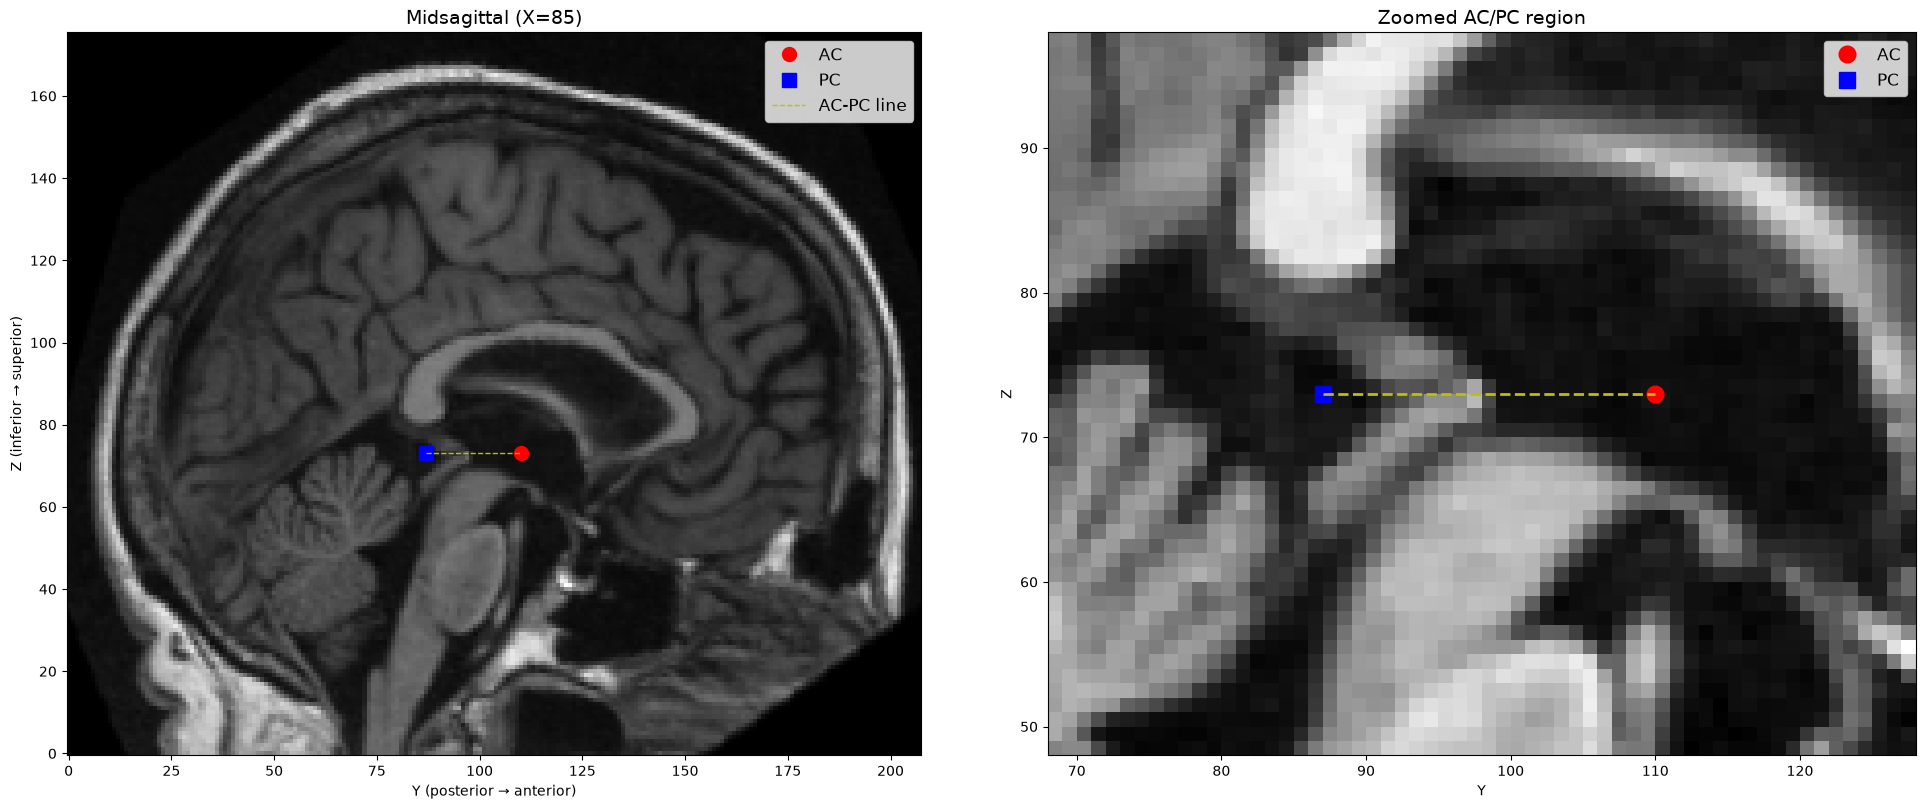

In [4]:
mid_x = AC['x']
msp = arr[:, :, mid_x]  # midsagittal slice, shape (Z, Y)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full midsagittal view
axes[0].imshow(msp, cmap='gray', origin='lower')
axes[0].plot(AC['y'], AC['z'], 'ro', markersize=10, label='AC')
axes[0].plot(PC['y'], PC['z'], 'bs', markersize=10, label='PC')
axes[0].plot([PC['y'], AC['y']], [PC['z'], AC['z']], 'y--', linewidth=1, label='AC-PC line')
axes[0].set_title(f'Midsagittal (X={mid_x})', fontsize=14)
axes[0].set_xlabel('Y (posterior → anterior)')
axes[0].set_ylabel('Z (inferior → superior)')
axes[0].legend(fontsize=12)

# Zoomed view around AC/PC
z_pad, y_pad = 25, 30
z_cen = (AC['z'] + PC['z']) // 2
y_cen = (AC['y'] + PC['y']) // 2
z_lo = max(0, z_cen - z_pad)
z_hi = min(msp.shape[0], z_cen + z_pad)
y_lo = max(0, y_cen - y_pad)
y_hi = min(msp.shape[1], y_cen + y_pad)

axes[1].imshow(msp[z_lo:z_hi, y_lo:y_hi], cmap='gray', origin='lower',
               extent=[y_lo, y_hi, z_lo, z_hi])
axes[1].plot(AC['y'], AC['z'], 'ro', markersize=12, label='AC')
axes[1].plot(PC['y'], PC['z'], 'bs', markersize=12, label='PC')
axes[1].plot([PC['y'], AC['y']], [PC['z'], AC['z']], 'y--', linewidth=2)
axes[1].set_title('Zoomed AC/PC region', fontsize=14)
axes[1].set_xlabel('Y')
axes[1].set_ylabel('Z')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

## Axial view at AC level

At the AC Z-level, you should see:
- The lateral ventricles (dark butterfly shape)
- AC marker (red) in the midline, at the anterior wall of the third ventricle
- PC marker (blue) behind it, at the posterior end of the 3V

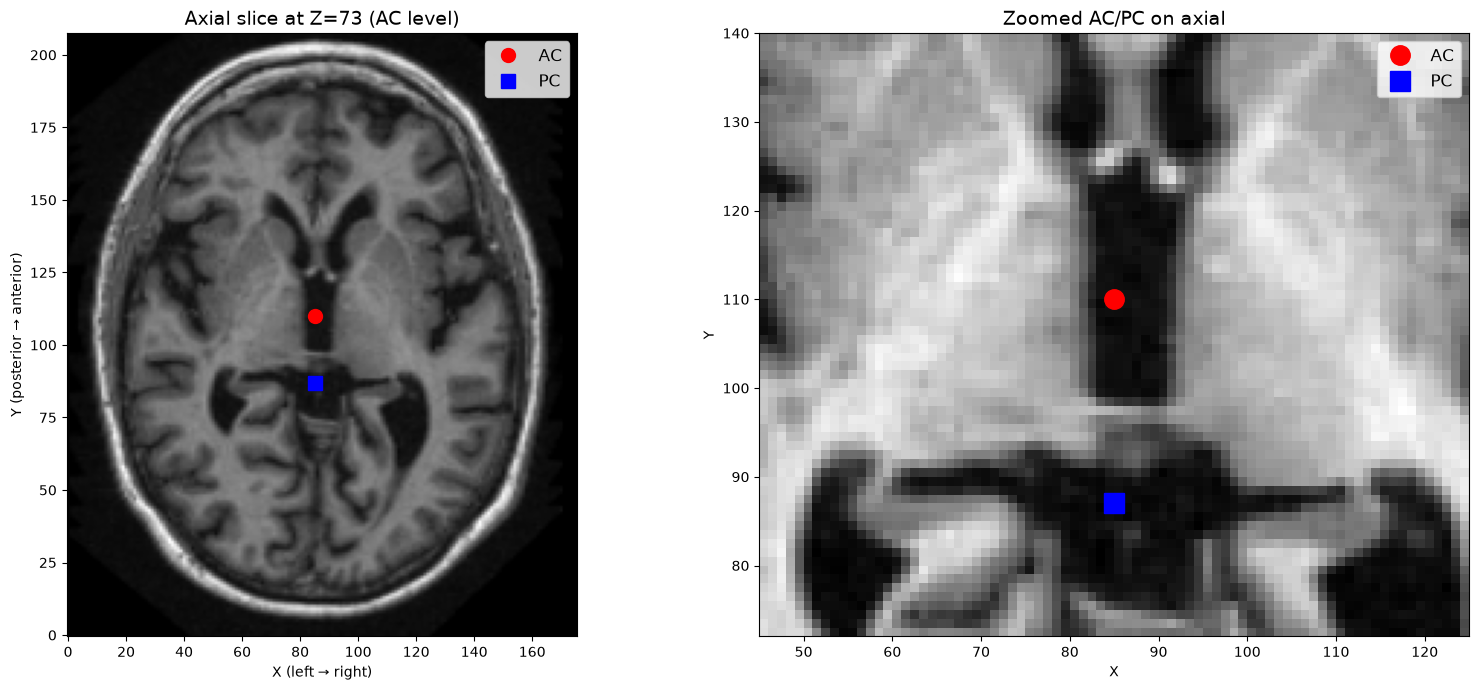

In [5]:
ax_slice = arr[AC['z'], :, :]  # shape (Y, X)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(ax_slice, cmap='gray', origin='lower')
axes[0].plot(AC['x'], AC['y'], 'ro', markersize=10, label='AC')
axes[0].plot(PC['x'], PC['y'], 'bs', markersize=10, label='PC')
axes[0].set_title(f'Axial slice at Z={AC["z"]} (AC level)', fontsize=14)
axes[0].set_xlabel('X (left → right)')
axes[0].set_ylabel('Y (posterior → anterior)')
axes[0].legend(fontsize=12)

# Zoomed
pad = 40
x_lo = max(0, AC['x'] - pad)
x_hi = min(ax_slice.shape[1], AC['x'] + pad)
y_lo = max(0, PC['y'] - 15)
y_hi = min(ax_slice.shape[0], AC['y'] + 30)

axes[1].imshow(ax_slice[y_lo:y_hi, x_lo:x_hi], cmap='gray', origin='lower',
               extent=[x_lo, x_hi, y_lo, y_hi])
axes[1].plot(AC['x'], AC['y'], 'ro', markersize=14, label='AC')
axes[1].plot(PC['x'], PC['y'], 'bs', markersize=14, label='PC')
axes[1].set_title('Zoomed AC/PC on axial', fontsize=14)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

## Coronal view at AC and PC levels

- **At AC (left)**: Should show lateral ventricles as dark regions, AC connects the two hemispheres
- **At PC (right)**: Should show the posterior part of the 3V, pineal region

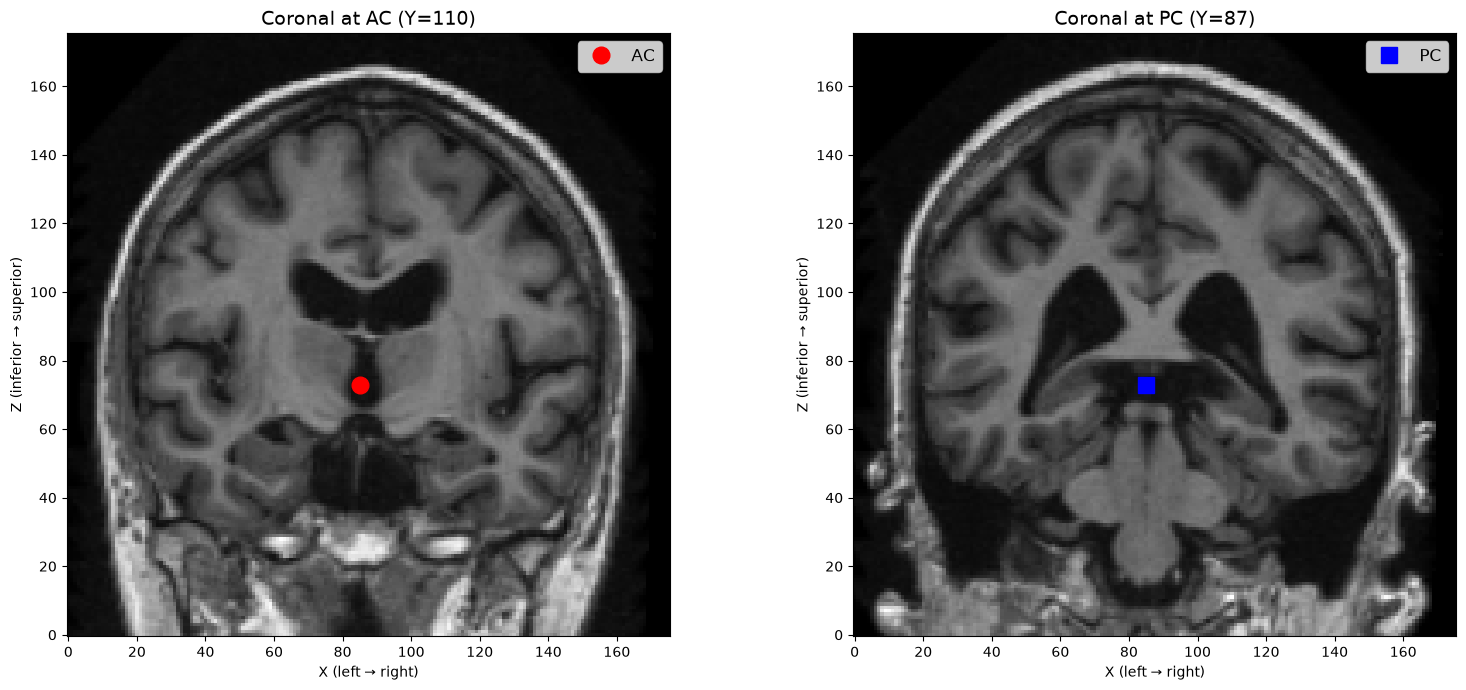

In [6]:
cor_ac = arr[:, AC['y'], :]  # coronal at AC, shape (Z, X)
cor_pc = arr[:, PC['y'], :]  # coronal at PC, shape (Z, X)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(cor_ac, cmap='gray', origin='lower')
axes[0].plot(AC['x'], AC['z'], 'ro', markersize=12, label='AC')
axes[0].set_title(f'Coronal at AC (Y={AC["y"]})', fontsize=14)
axes[0].set_xlabel('X (left → right)')
axes[0].set_ylabel('Z (inferior → superior)')
axes[0].legend(fontsize=12)

axes[1].imshow(cor_pc, cmap='gray', origin='lower')
axes[1].plot(PC['x'], PC['z'], 'bs', markersize=12, label='PC')
axes[1].set_title(f'Coronal at PC (Y={PC["y"]})', fontsize=14)
axes[1].set_xlabel('X (left → right)')
axes[1].set_ylabel('Z (inferior → superior)')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

## Cross-check with a second subject

Since all T88 volumes share the same atlas, AC/PC should be at the same voxel for every subject.

Cross-checking with: OAS1_0006_MR1


NiftiImageIO (0x9964fc380): data/oasis1/disc1/OAS1_0006_MR1/PROCESSED/MPRAGE/T88_111/OAS1_0006_MR1_mpr_n4_anon_111_t88_gfc.img is Analyze file and it's deprecated 

NiftiImageIO (0x9964fc380): data/oasis1/disc1/OAS1_0006_MR1/PROCESSED/MPRAGE/T88_111/OAS1_0006_MR1_mpr_n4_anon_111_t88_gfc.img is Analyze file and it's deprecated 



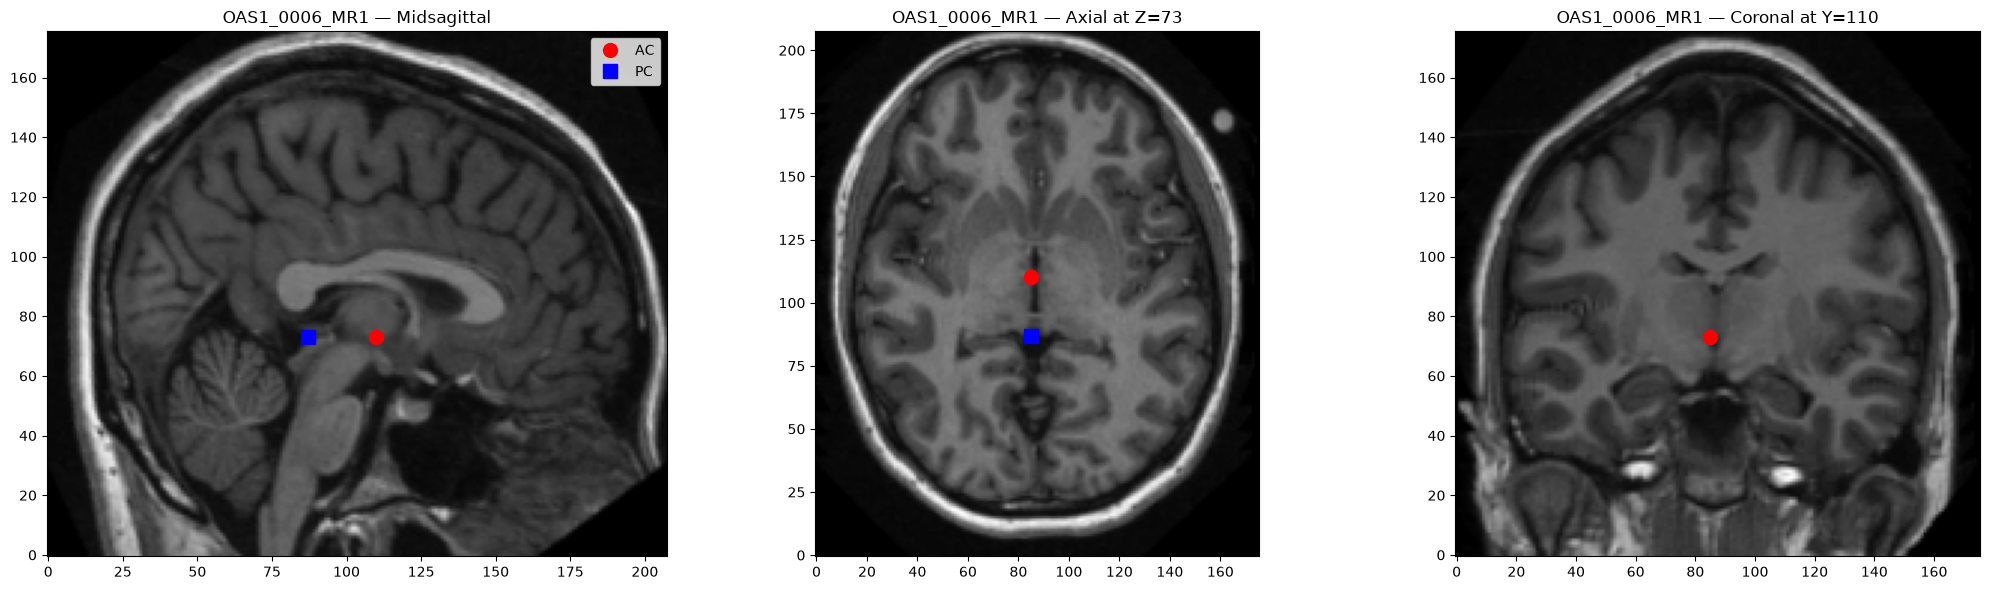

In [7]:
import glob

# Pick a different subject
gfc_files = sorted(glob.glob('data/oasis1/disc1/OAS1_*/PROCESSED/MPRAGE/T88_111/*_t88_gfc.img'))
subj2_path = gfc_files[5]  # 6th subject
subj2_id = subj2_path.split('/')[3]
print(f'Cross-checking with: {subj2_id}')

img2 = sitk.ReadImage(subj2_path)
arr2 = sitk.GetArrayFromImage(img2)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Midsagittal
axes[0].imshow(arr2[:, :, AC['x']], cmap='gray', origin='lower')
axes[0].plot(AC['y'], AC['z'], 'ro', markersize=10, label='AC')
axes[0].plot(PC['y'], PC['z'], 'bs', markersize=10, label='PC')
axes[0].set_title(f'{subj2_id} — Midsagittal', fontsize=12)
axes[0].legend()

# Axial at AC level
axes[1].imshow(arr2[AC['z'], :, :], cmap='gray', origin='lower')
axes[1].plot(AC['x'], AC['y'], 'ro', markersize=10)
axes[1].plot(PC['x'], PC['y'], 'bs', markersize=10)
axes[1].set_title(f'{subj2_id} — Axial at Z={AC["z"]}', fontsize=12)

# Coronal at AC level
axes[2].imshow(arr2[:, AC['y'], :], cmap='gray', origin='lower')
axes[2].plot(AC['x'], AC['z'], 'ro', markersize=10)
axes[2].set_title(f'{subj2_id} — Coronal at Y={AC["y"]}', fontsize=12)

plt.tight_layout()
plt.show()

## Final AC/PC values

If the markers look correct above, these are the values to use for all OASIS T88 feature extraction.
If they're off, adjust the `AC` and `PC` dicts in cell 4 and re-run.

In [8]:
print('=== OASIS T88_111 AC/PC Coordinates (0-indexed) ===')
print(f'AC voxel (X, Y, Z) = ({AC["x"]}, {AC["y"]}, {AC["z"]})')
print(f'PC voxel (X, Y, Z) = ({PC["x"]}, {PC["y"]}, {PC["z"]})')
print(f'AC-PC distance: {acpc_dist:.1f} mm')
print()
print('In numpy array indexing (Z, Y, X):')
print(f'AC = arr[{AC["z"]}, {AC["y"]}, {AC["x"]}]')
print(f'PC = arr[{PC["z"]}, {PC["y"]}, {PC["x"]}]')

=== OASIS T88_111 AC/PC Coordinates (0-indexed) ===
AC voxel (X, Y, Z) = (85, 110, 73)
PC voxel (X, Y, Z) = (85, 87, 73)
AC-PC distance: 23.0 mm

In numpy array indexing (Z, Y, X):
AC = arr[73, 110, 85]
PC = arr[73, 87, 85]
